# Spatio-Temporal Geospatial Outlier Detection (GBSO_ST)
## Case Study: Urban Noise in Barcelona (2023)

This notebook demonstrates the use of the **Spatio-Temporal Graph-Based Spatial Outlier (GBSO_ST)** algorithm, an extension of the static geospatial outlier detection methodology.

While the static algorithms (GBSO, SWOD) compare an observation against its spatial neighbours at a single point in time, **GBSO_ST** compares a time series of observations against the spatio-temporal distribution of its Voronoi neighbours within a sliding time window.

This allows us to answer questions like:
> *Is this sensor unusually noisy right now, compared to what its immediate geographic neighbours have been recording over the last 24 hours?*

### 1. Setup and Imports

In [1]:
import sys
import os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi
import networkx as nx

from src.models import GBSO_ST

# Plotting settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')


### 2. Generate Synthetic Spatio-Temporal Data
Instead of loading the massive 800,000+ observations dataset of Barcelona, we will generate a synthetic spatio-temporal dataset that mimics urban noise sensors. We will simulate 20 sensors over 7 days (168 hours).

In [2]:
# 20 sensors in a 2D space (simulating coordinates)
np.random.seed(42)
N = 20
T = 168 # 7 days * 24 hours
coords = np.random.rand(N, 2) * 100

# Base noise level for each sensor (between 50 and 70 dB)
base_levels = np.random.uniform(50, 70, size=N)

# Generate time series with daily seasonality
time = np.arange(T)
daily_pattern = 5 * np.sin(2 * np.pi * time / 24) # ±5 dB daily variation

# Matrix of observations (T x N)
Y_matrix = np.zeros((T, N))
for i in range(N):
    # Base + daily pattern + random noise
    Y_matrix[:, i] = base_levels[i] + daily_pattern + np.random.normal(0, 2, size=T)

# INTRODUCE ANOMALIES
# 1. Spatial Anomaly: Sensor 5 is structurally much louder than its neighbours
Y_matrix[:, 5] += 15 

# 2. Spatio-Temporal Anomaly: Sensor 12 has a sudden noise event on day 4 (hours 72 to 80)
Y_matrix[72:80, 12] += 25

print(f"Generated data matrix: {Y_matrix.shape} (Time x Sensors)")


Generated data matrix: (168, 20) (Time x Sensors)


### 3. Build the Static Voronoi Neighbourhood
The spatial relationships are fixed over time. We compute the Voronoi diagram once.

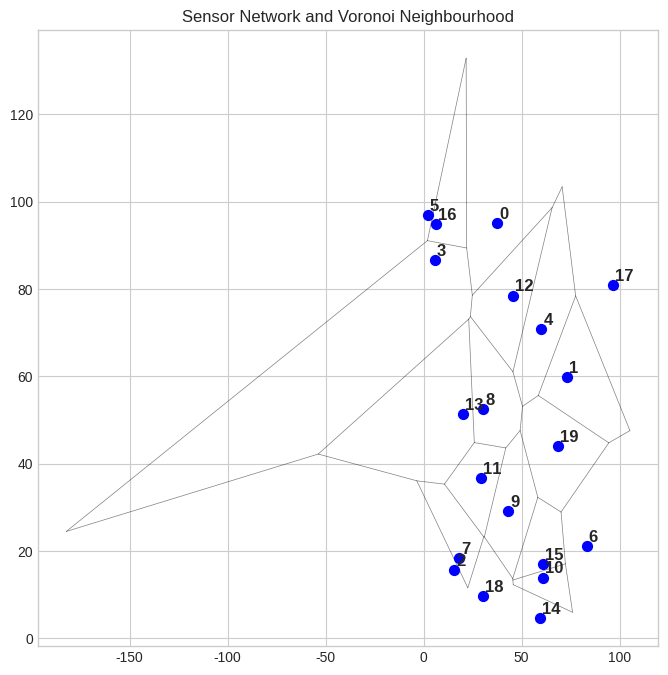

In [3]:
# Build Voronoi and Adjacency Matrix
dv = Voronoi(coords, qhull_options="QJ")
G = nx.Graph()
G.add_nodes_from(range(N))
G.add_edges_from(dv.ridge_points)
adj = nx.adjacency_matrix(G).toarray().astype(float)

# Extract list of neighbours for each sensor
Vnn = [list(np.where(adj[i, :] == 1)[0]) for i in range(N)]

# Plot the network
fig, ax = plt.subplots(figsize=(8, 8))
for simplex in dv.ridge_vertices:
    simplex = np.asarray(simplex)
    if np.all(simplex >= 0):
        ax.plot(dv.vertices[simplex, 0], dv.vertices[simplex, 1], 'k-', lw=0.5, alpha=0.5)

ax.scatter(coords[:, 0], coords[:, 1], c='blue', s=50, zorder=3)
for i in range(N):
    ax.annotate(str(i), (coords[i, 0]+1, coords[i, 1]+1), fontsize=12, fontweight='bold')
    
ax.set_title("Sensor Network and Voronoi Neighbourhood")
plt.show()


### 4. Execute GBSO_ST Algorithm
We run the algorithm with a temporal window of $k=12$ (±12 hours).

In [4]:
# Execute GBSO_ST
k_window = 12
theta_threshold = 2.0

scores, mu_st, is_outlier = GBSO_ST(
    Y_matrix=Y_matrix, 
    Vnn=Vnn, 
    k=k_window, 
    theta=theta_threshold, 
    verbose=True
)

print(f"\nScores matrix shape: {scores.shape}")
print(f"Total outliers detected: {np.nansum(is_outlier)}")


  GBSO_ST | T=168 steps, N=20 observations, window k=12 (±12 steps = 25 total)

Scores matrix shape: (168, 20)
Total outliers detected: 167


### 5. Analyse the Results

Let's look at the two sensors where we introduced anomalies:
1. **Sensor 5** (Structural spatial anomaly)
2. **Sensor 12** (Spatio-temporal event)

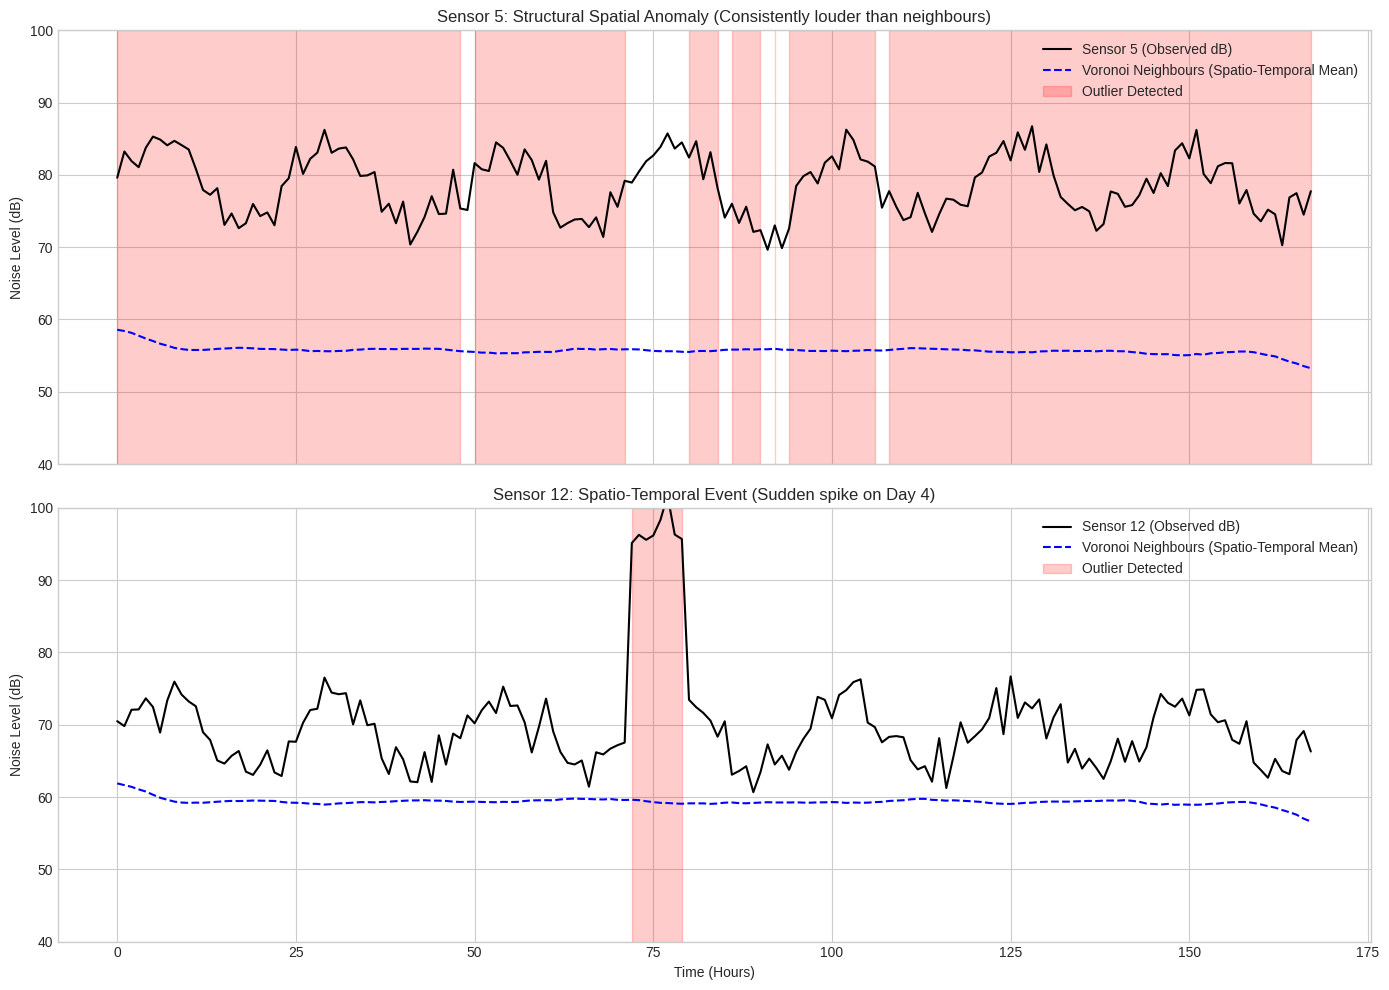

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot Sensor 5
ax = axes[0]
ax.plot(time, Y_matrix[:, 5], label='Sensor 5 (Observed dB)', color='black', lw=1.5)
ax.plot(time, mu_st[:, 5], label='Voronoi Neighbours (Spatio-Temporal Mean)', color='blue', linestyle='--')
ax.fill_between(time, 0, 100, where=is_outlier[:, 5], color='red', alpha=0.2, label='Outlier Detected')
ax.set_title("Sensor 5: Structural Spatial Anomaly (Consistently louder than neighbours)")
ax.set_ylabel("Noise Level (dB)")
ax.legend(loc='upper right')
ax.set_ylim(40, 100)

# Plot Sensor 12
ax = axes[1]
ax.plot(time, Y_matrix[:, 12], label='Sensor 12 (Observed dB)', color='black', lw=1.5)
ax.plot(time, mu_st[:, 12], label='Voronoi Neighbours (Spatio-Temporal Mean)', color='blue', linestyle='--')
ax.fill_between(time, 0, 100, where=is_outlier[:, 12], color='red', alpha=0.2, label='Outlier Detected')
ax.set_title("Sensor 12: Spatio-Temporal Event (Sudden spike on Day 4)")
ax.set_ylabel("Noise Level (dB)")
ax.set_xlabel("Time (Hours)")
ax.legend(loc='upper right')
ax.set_ylim(40, 100)

plt.tight_layout()
plt.show()


### 6. Conclusion
The GBSO_ST algorithm successfully identifies both types of anomalies:
- **Sensor 5** is flagged as an outlier almost continuously because its values are systematically higher than the spatio-temporal distribution of its neighbours.
- **Sensor 12** is only flagged during the specific hours (72-80) where its values diverge significantly from what its neighbours have been experiencing in the recent temporal window.

This makes GBSO_ST a powerful tool for monitoring sensor networks over time, capable of distinguishing between structural geographic disparities and sudden local events.